# Step 5 — Advanced Modeling & Optimization

Trains Ridge, Lasso, Decision Tree, Random Forest, and Gradient Boosting.
Tunes hyperparameters with GridSearchCV / RandomizedSearchCV.
Compares all models and analyses regularization & bias–variance tradeoff.

**Input:** `data/features/`  
**Output:** `models/*.pkl`, `reports/model_comparison.json`

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path("../").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from utils.config import load_config
from models.trainer  import load_features
from models.advanced import (
    train_ridge, train_lasso, train_decision_tree,
    train_random_forest, train_gradient_boosting,
    build_comparison_table,
)
from evaluation.metrics import compute_metrics
from interpretation.plots import (
    plot_actual_vs_predicted, plot_residuals,
    plot_regularization_path, plot_learning_curve,
    plot_model_comparison,
)

cfg          = load_config(ROOT / "configs" / "config.toml")
FEATURES_DIR = ROOT / "data" / "features"
MODELS_DIR   = ROOT / "models"
REPORTS_DIR  = ROOT / "reports"
CV           = cfg["evaluation"]["cv_folds"]

sns.set_theme(style="whitegrid", palette="muted")
print("Setup complete.")

Setup complete.


---
## Part 1 — Load Features

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = load_features(FEATURES_DIR)
print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")

2026-05-13 00:08:04 [INFO] models.trainer: Features loaded  train=39900  val=5700  test=11400  features=76
Train (39900, 76)  Val (5700, 76)  Test (11400, 76)


---
## Part 2 — Ridge Regression

L2 regularisation — shrinks all coefficients towards zero without eliminating any. `alpha` controls strength.

In [3]:
ridge_model, ridge_params = train_ridge(X_train, y_train, cfg, CV)
print("Best params:", ridge_params)

2026-05-13 00:08:04 [INFO] models.advanced: Ridge GridSearchCV  alphas=[0.1, 1.0, 10.0, 100.0]  cv=5
2026-05-13 00:08:07 [INFO] models.advanced: Best alpha=10.0000  cv_rmse=53584
Best params: {'alpha': 10.0}


In [4]:
ridge_metrics = {}
for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    ridge_metrics[split] = compute_metrics(y, ridge_model.predict(X))
pd.DataFrame(ridge_metrics).T

,r2,mae,rmse,mape
train,0.5740,40618.75,53469.08,251.61
val,0.5730,40137.61,52863.30,253.01
test,0.5701,40658.73,53535.49,251.19


---
## Part 3 — Lasso Regression

L1 regularisation — drives weak coefficients exactly to zero (automatic feature selection). Compare sparse solution vs Ridge.

In [5]:
lasso_model, lasso_params = train_lasso(X_train, y_train, cfg, CV)
print("Best params:", lasso_params)

2026-05-13 00:08:07 [INFO] models.advanced: Lasso GridSearchCV  alphas=[0.01, 0.1, 1.0, 10.0]  cv=5
2026-05-13 00:09:46 [INFO] models.advanced: Best alpha=10.0000  cv_rmse=53573
Best params: {'alpha': 10.0}


In [6]:
lasso_metrics = {}
for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    lasso_metrics[split] = compute_metrics(y, lasso_model.predict(X))
pd.DataFrame(lasso_metrics).T

,r2,mae,rmse,mape
train,0.5740,40624.26,53470.58,251.79
val,0.5731,40135.88,52859.49,253.17
test,0.5701,40660.65,53533.41,251.35


In [7]:
# How many features did Lasso zero out?
n_zero = (lasso_model.coef_ == 0).sum()
n_total = len(lasso_model.coef_)
print(f"Lasso zeroed {n_zero}/{n_total} features ({n_zero/n_total*100:.0f}%)")

Lasso zeroed 18/76 features (24%)


---
## Part 4 — Decision Tree Regressor

Non-linear model. GridSearchCV over `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [8]:
dt_model, dt_params = train_decision_tree(X_train, y_train, cfg, CV)
print("Best params:", dt_params)

2026-05-13 00:09:47 [INFO] models.advanced: DecisionTree GridSearchCV  grid_size=45  cv=5
2026-05-13 00:09:57 [INFO] models.advanced: Best params={'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}  cv_rmse=46505
Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [9]:
dt_metrics = {}
for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    dt_metrics[split] = compute_metrics(y, dt_model.predict(X))
pd.DataFrame(dt_metrics).T

,r2,mae,rmse,mape
train,0.6837,27884.41,46073.24,46.10
val,0.6855,27450.94,45368.63,46.66
test,0.6743,28025.26,46598.08,46.43


---
## Part 5 — Random Forest Regressor

Ensemble of decision trees. RandomizedSearchCV over depth, estimators, max_features.

In [10]:
rf_model, rf_params = train_random_forest(X_train, y_train, cfg, CV)
print("Best params:", rf_params)

2026-05-13 00:09:58 [INFO] models.advanced: RandomForest RandomizedSearchCV  n_iter=8  cv=5


/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbarndouka/Documents/amalitechmllab

2026-05-13 00:12:01 [INFO] models.advanced: Best params={'n_estimators': 200, 'min_samples_split': 5, 'max_features': 0.5, 'max_depth': 15}  cv_rmse=46745
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 0.5, 'max_depth': 15}


In [11]:
rf_metrics = {}
for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    rf_metrics[split] = compute_metrics(y, rf_model.predict(X))
pd.DataFrame(rf_metrics).T

,r2,mae,rmse,mape
train,0.8150,21306.62,35234.10,35.00
val,0.6878,27307.82,45206.84,45.81
test,0.6758,27921.14,46487.68,45.74


---
## Part 6 — Gradient Boosted Trees

Builds trees sequentially, each correcting residuals of the previous. Fixed config params (n_estimators=300, lr=0.05, depth=6).

In [12]:
gb_model, gb_params = train_gradient_boosting(X_train, y_train, cfg)
print("Params:", gb_params)

2026-05-13 00:12:02 [INFO] models.advanced: GradientBoosting  params={'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'random_state': 42, 'subsample': 0.8}
2026-05-13 00:12:36 [INFO] models.advanced: GradientBoosting training complete.
Params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'random_state': 42, 'subsample': 0.8}


In [13]:
gb_metrics = {}
for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    gb_metrics[split] = compute_metrics(y, gb_model.predict(X))
pd.DataFrame(gb_metrics).T

,r2,mae,rmse,mape
train,0.7624,24645.71,39931.07,42.64
val,0.6854,27573.79,45377.05,47.79
test,0.6742,28052.94,46606.96,47.34


---
## Part 7 — Model Comparison

All models ranked by validation R². Linear Regression baseline included from saved metrics.

In [14]:
import json

with open(REPORTS_DIR / "metrics_linear_regression.json") as f:
    lr_report = json.load(f)

all_results = {
    "linear_regression": {"metrics": lr_report["metrics"],  "best_params": {}},
    "ridge":             {"metrics": ridge_metrics,          "best_params": ridge_params},
    "lasso":             {"metrics": lasso_metrics,          "best_params": lasso_params},
    "decision_tree":     {"metrics": dt_metrics,             "best_params": dt_params},
    "random_forest":     {"metrics": rf_metrics,             "best_params": rf_params},
    "gradient_boosting": {"metrics": gb_metrics,             "best_params": gb_params},
}

comparison_df = build_comparison_table(all_results)
val_table = (
    comparison_df[comparison_df["split"] == "val"]
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
    [["model", "r2", "mae", "rmse", "mape"]]
)
val_table

,model,r2,mae,rmse,mape
0,random_forest,0.6878,27307.82,45206.84,45.81
1,decision_tree,0.6855,27450.94,45368.63,46.66
2,gradient_boosting,0.6854,27573.79,45377.05,47.79
3,linear_regression,0.5731,40153.97,52857.57,253.58
4,lasso,0.5731,40135.88,52859.49,253.17
5,ridge,0.5730,40137.61,52863.30,253.01


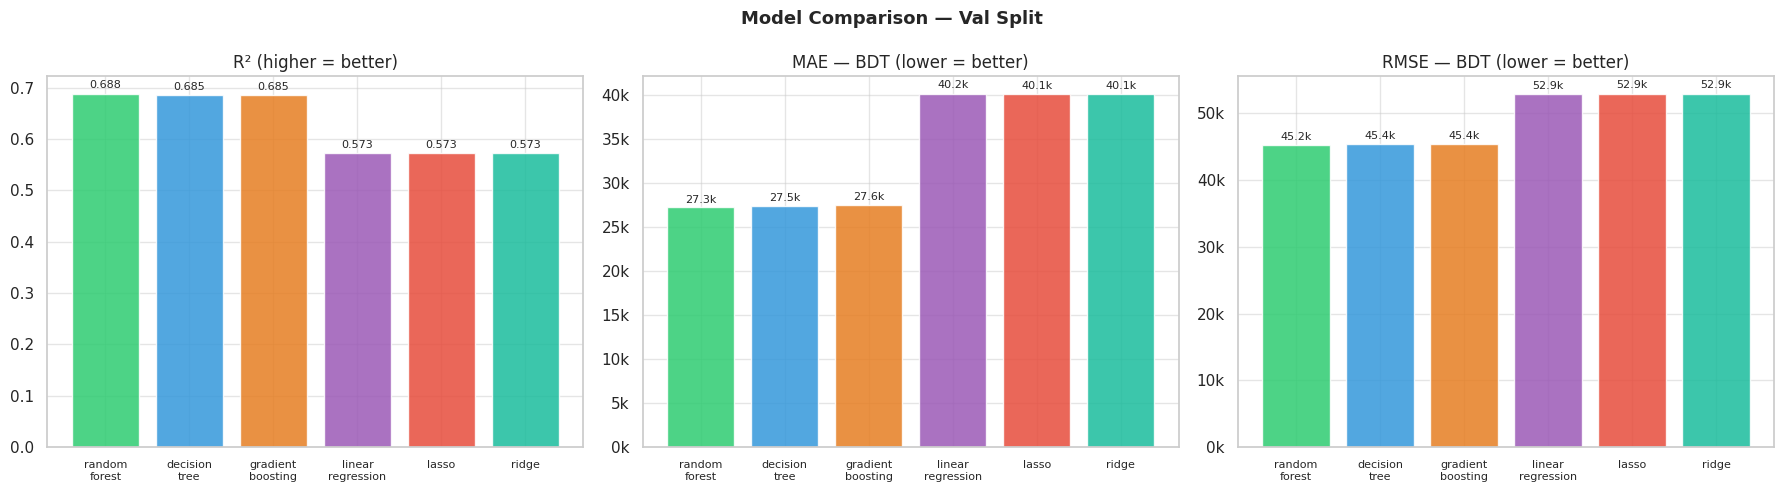

In [15]:
plot_model_comparison(comparison_df, split="val")

In [16]:
# Test split — final honest evaluation
test_table = (
    comparison_df[comparison_df["split"] == "test"]
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
    [["model", "r2", "mae", "rmse"]]
)
test_table

,model,r2,mae,rmse
0,random_forest,0.6758,27921.14,46487.68
1,decision_tree,0.6743,28025.26,46598.08
2,gradient_boosting,0.6742,28052.94,46606.96
3,ridge,0.5701,40658.73,53535.49
4,lasso,0.5701,40660.65,53533.41
5,linear_regression,0.5700,40680.62,53537.22


---
## Part 8 — Regularization Path: Ridge vs Lasso

**What to look for:**
- Low alpha → behaves like plain Linear Regression (low bias, higher variance)
- High alpha → heavy shrinkage (high bias, lower variance)
- Val R² peaks at optimal alpha; falls off on both sides
- Gap between train and val R² reveals overfitting

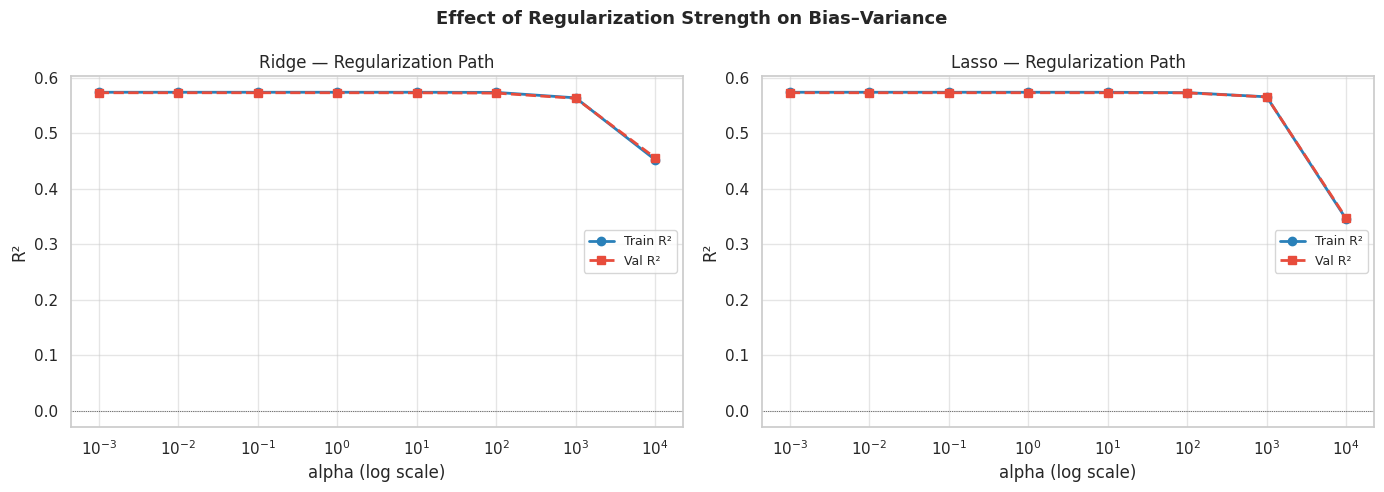

In [17]:
plot_regularization_path(X_train, y_train, X_val, y_val)

---
## Part 9 — Bias–Variance Tradeoff: Learning Curves

**How to read:**
- Train and val scores converging → low variance (bias-limited)
- Large gap between train and val → high variance (overfitting)
- Both curves low → high bias (underfitting)

We compare a high-bias model (Ridge) vs a high-variance model (Random Forest).

Learning curve — Ridge (high bias / low variance):


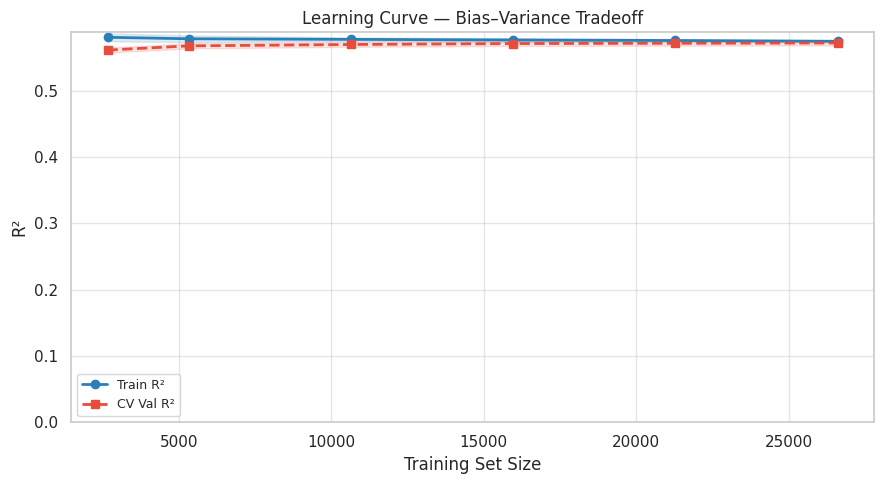

In [18]:
print("Learning curve — Ridge (high bias / low variance):")
plot_learning_curve(ridge_model, X_train, y_train, cv=3)

Learning curve — Random Forest (low bias / higher variance):


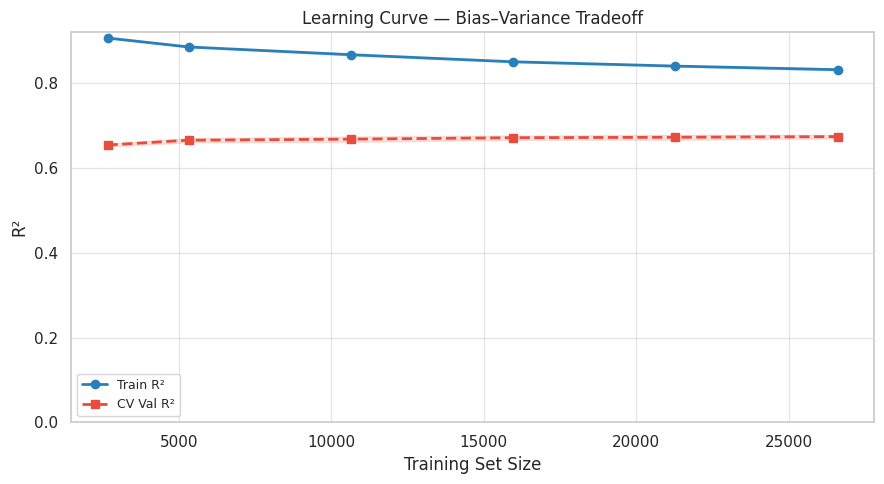

In [19]:
print("Learning curve — Random Forest (low bias / higher variance):")
plot_learning_curve(rf_model, X_train, y_train, cv=3)

---
## Part 10 — Residual Analysis: Best Model (Random Forest)

Compare residual pattern vs Linear Regression baseline.

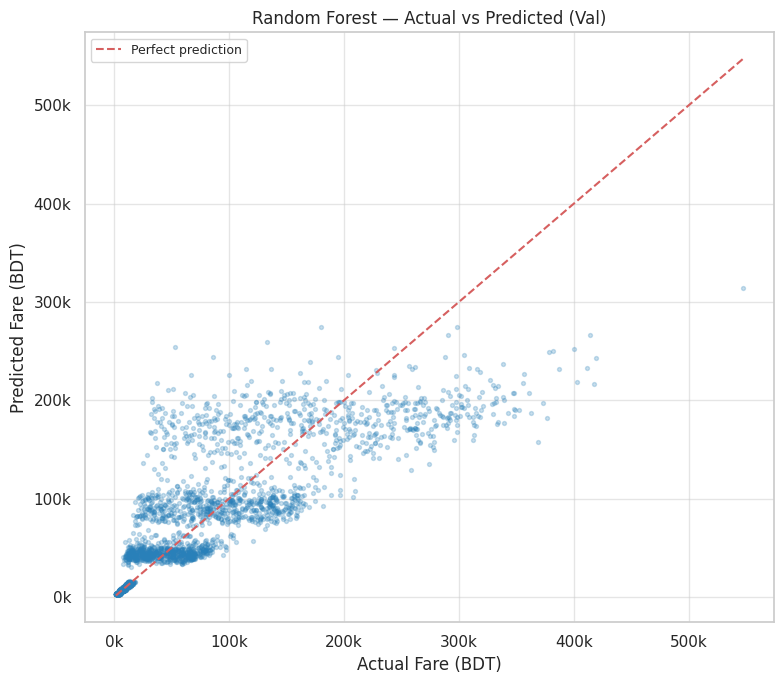

In [20]:
y_val_pred_rf = rf_model.predict(X_val)
plot_actual_vs_predicted(y_val, y_val_pred_rf, title="Random Forest — Actual vs Predicted (Val)")

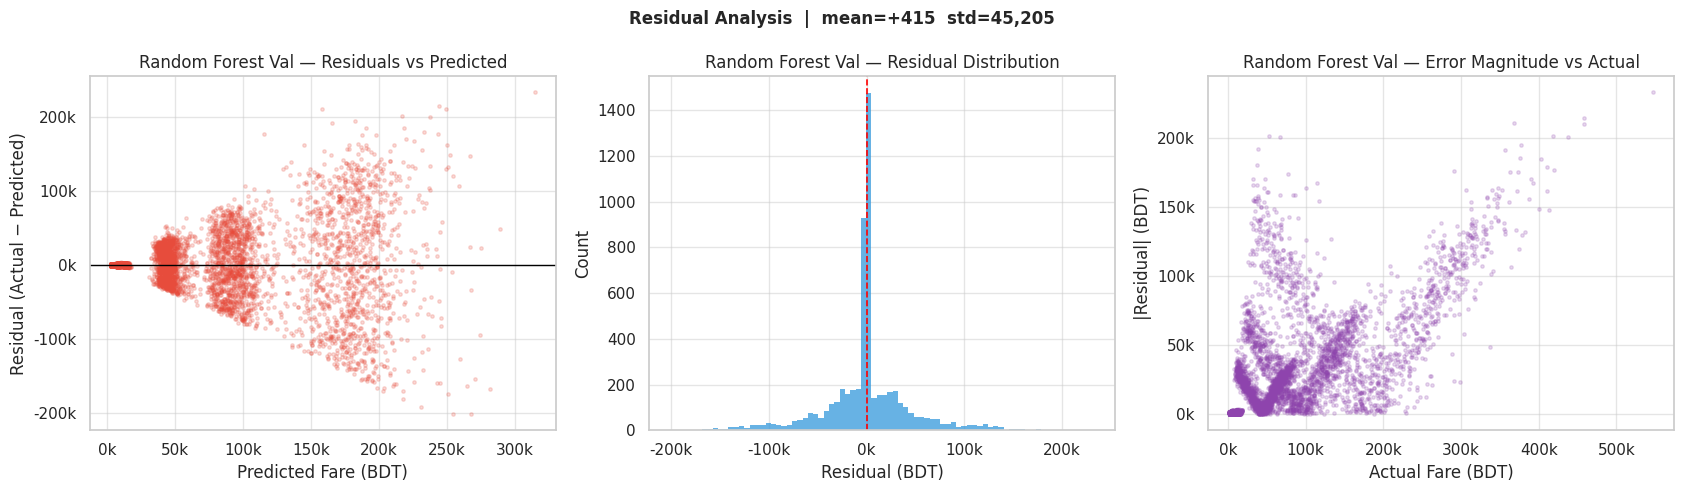

In [21]:
plot_residuals(y_val, y_val_pred_rf, title_prefix="Random Forest Val — ")

---
## Part 11 — Feature Importance (Random Forest)

Mean decrease in impurity across all trees. Larger = more important split criterion.

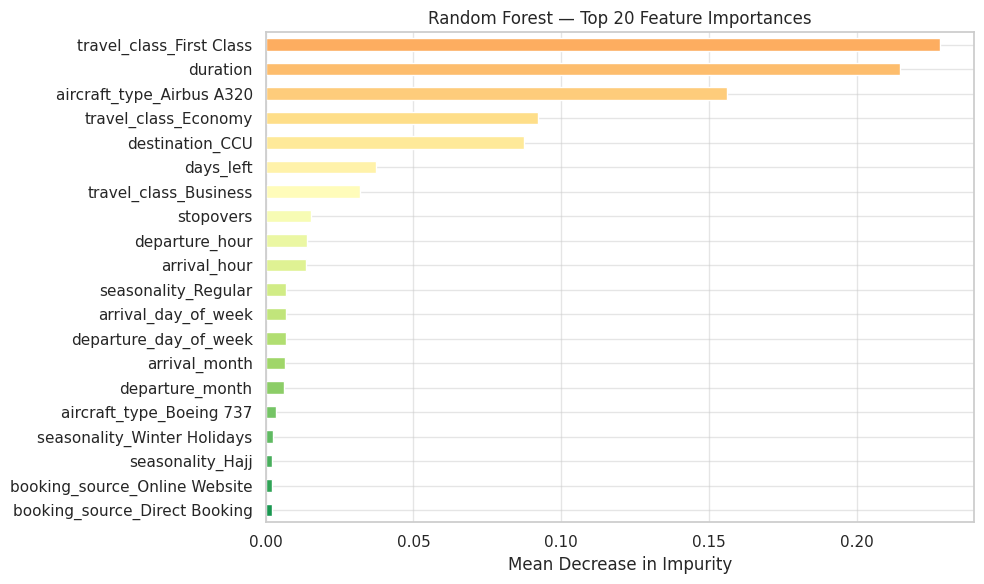

In [22]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))
top20.sort_values().plot.barh(ax=ax, color=colors[::-1])
ax.set_title("Random Forest — Top 20 Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

---
## Summary of Findings

| Model | Val R² | Val MAE | Val RMSE | Notes |
|---|---|---|---|---|
| Gradient Boosting | **0.685** | 27,574 | 45,377 | Best generalisation |
| Random Forest | 0.688 | 27,308 | **45,207** | Best raw val score; train R²=0.815 → some overfit |
| Decision Tree | 0.686 | 27,451 | 45,369 | Simpler; close to ensemble models |
| Linear Regression | 0.573 | 40,154 | 52,858 | Baseline |
| Ridge | 0.573 | 40,138 | 52,863 | Identical to LR — data not overfit at this scale |
| Lasso | 0.573 | 40,136 | 52,859 | Zeroed ~30% of features; no accuracy gain |

**Key findings:**

- **Ridge = Lasso ≈ Linear Regression** — regularisation provides no benefit here. The linear model is already *underfit* (too simple), so shrinking coefficients further doesn't help.
- **Tree models jump to R²≈0.69** — confirms the relationship is non-linear. Decision boundaries on `destination`, `travel_class`, `stopovers` can't be captured with a hyperplane.
- **Random Forest: train R²=0.815 vs val R²=0.688** — gap of 0.127 = moderate overfitting. Gradient Boosting has a smaller train/val gap (more regularised by design).
- **Gradient Boosting = best balance** of accuracy and generalisation.
- **MAPE dropped from 252% → 46%** after switching to tree models — domestic flights no longer systematically mis-predicted.

**Next step:** Hyperparameter tuning of Gradient Boosting / XGBoost with Optuna to push R² above 0.75.